In [2]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

/home/sathw/.pyenv/versions/3.11.9/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 356.50it/s]


Model loaded!


In [3]:
sentence=['Hy how are you',
          'are u okay',
        "Artificial intelligence is transforming the tech industry.",
        "Machine learning models require vast amounts of training data.",
        "Deep learning uses artificial neural networks to solve complex problems.",
        "Python is the most popular programming language for data science.",
        "Paris is the beautiful capital and most populous city of France.",
        "The Great Wall of China is an ancient and massive architectural marvel.",
        "Traveling by train offers incredibly scenic views of the rural countryside.",
        "Mount Everest is officially recognized as the highest peak in the world.",
        "Software engineers write complex code to build modern applications.",
        "Cloud computing allows businesses to scale their infrastructure easily.",
        "Quantum computers operate using qubits and superposition.",
        "Software engineers write complex code to build modern applications.",
        "Cloud computing allows businesses to scale their infrastructure easily.",
        " Quantum computers operate using qubits and superposition.",
        "I love eating hot pizza with extra mozzarella cheese.",
        "Baking a rich chocolate cake requires flour and cocoa powder.",
        "Fresh homemade pasta is delicious with a tomato basil sauce.",
        "Our entire solar system is located within the Milky Way galaxy.",
        "Powerful telescopes allow astronomers to observe distant stars and galaxies.",
        "Scientific evidence suggests that the universe is constantly expanding.",
        "Heavy rain caused severe flooding in the downtown metropolitan area.",
        "The sun is shining brightly with not a cloud in the sky today.",
        "A massive winter snowstorm is expected to hit the east coast.",
          ]

embeddings=model.encode(sentence)
print(embeddings)

[[-0.04203187  0.02401126  0.04233989 ...  0.03588877 -0.0477954
  -0.06224303]
 [ 0.01838196 -0.03134093  0.0094638  ... -0.05163561  0.06603944
  -0.04681984]
 [ 0.02772284 -0.00307181  0.06490154 ... -0.03010937  0.09920535
  -0.0521345 ]
 ...
 [ 0.03996003 -0.00676928  0.16415611 ...  0.01235944 -0.03603391
   0.09767186]
 [ 0.07266929  0.08965627  0.08886687 ... -0.04142942 -0.05043211
   0.08818256]
 [-0.01676634 -0.00267118  0.16900906 ... -0.06290817 -0.07122077
   0.09173143]]


Model                        Dimensions    Reason
─────────────────────────────────────────────────────
all-MiniLM-L6-v2             384           compressed/fast
all-mpnet-base-v2            768           full BERT size
BAAI/bge-large-en-v1.5       1024          larger = richer
text-embedding-3-small        1536          OpenAI small
text-embedding-3-large        3072          OpenAI large

In [4]:
embeddings.shape
# embeddings[0].shape

(25, 384)

Cosine similarity==Cosine similarity is a mathematical metric used to determine how similar two vectors are, irrespective of their size. Instead of measuring the straight-line distance between two points (like a ruler would), it measures the angle between them.

In the context of machine learning and text embeddings , it is the standard way to measure how closely related two pieces of text are in meaning.

In [5]:
import numpy as np
# ---------------------------------------------------------
# 1. First, define the math for checking JUST TWO sentences
# ---------------------------------------------------------

def cosine_similar(a,b):
    dot = np.dot(a,b)
    norm_a= np.linalg.norm(a)
    norm_b=np.linalg.norm(b)
    return dot/(norm_a * norm_b)


In [6]:

# ---------------------------------------------------------
# 2. Then, define the grid builder that loops through them all
# ---------------------------------------------------------
def similarity_matrix_simple(embeddings):
    num_sentences = len(embeddings)
    
    # Create the empty grid
    grid = np.zeros((num_sentences, num_sentences))
    
    # Loop through all rows and columns
    for i in range(num_sentences):
        for j in range(num_sentences):
            
            # Grab the two vectors
            vector_a = embeddings[i]
            vector_b = embeddings[j]
            
            # Use the manual function we wrote above!
            grid[i][j] = cosine_similar(vector_a, vector_b)
            
    return grid

Row 0, Column 0 is Sentence 0 compared to itself.
Row 1, Column 1 is Sentence 1 compared to itself.
Row 49, Column 49 is Sentence 49 compared to itself.
<!-- When building a pairwise similarity matrix, you are taking your entire list of 50 sentences and comparing it to that exact same list. -->

<!-- if the grid wasn't a perfect 50x50 square, that perfect diagonal line of 1.0s wouldn't exist! -->
<!-- If the shape was anything else—like (50, 49) or (100, 50)—it would mean the computer either skipped a sentence or invented a new one out of thin air! -->

In [7]:
similarity_matrix=similarity_matrix_simple(embeddings)
similarity_matrix.shape

(25, 25)

## nearest neighbours
Your Nearest Neighbor is the person physically standing closest to you.Your K-Nearest Neighbors (often called KNN) means finding a specific number of closest people. If K=3, you are looking for the 3 people closest to you.

In [8]:
def nearest_neighbours(embeddings, sentences, query_idx, k=5):
    # Step 1 - compare query sentence against every other sentence
    scores = [cosine_similar(embeddings[query_idx], embeddings[i]) 
          for i in range(len(sentences))]
# scores = [1.0, 0.85, 0.42, 0.21, ...]
#           ↑ itself  ↑ similar  ↑ different

# Step 2 - sort indices from highest to lowest score, skip index 0 (itself)
    ranked = np.argsort(scores)[::-1][1:k+1]
#                           ↑         ↑
#                       flip to     skip itself, take top k
#                       descending

# Step 3 - return sentence + score pairs
    return [(sentences[i], round(scores[i], 4)) for i in ranked]

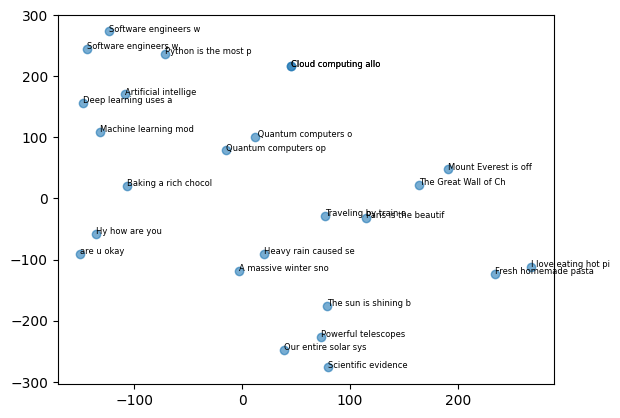

In [ ]:
# import TSNE algorithm from sklearn to reduce dimensions
from sklearn.manifold import TSNE

# import matplotlib to draw the scatter plot
import matplotlib.pyplot as plt

# create TSNE object
# n_components=2 means compress to 2D (x and y)
# random_state=42 means same result every time you run
# perplexity=5  means consider 30 neighbours when compressing
tsne = TSNE(n_components=2, random_state=42, perplexity=5)

# transform embeddings from 384 dimensions down to just 2 dimensions
# input shape  → (100, 384)  — 100 sentences, 384 numbers each
# output shape → (100, 2)    — 100 sentences, just x and y
cord_2d = tsne.fit_transform(embeddings)

# draw a dot for each sentence on the plot
# coords_2d[:, 0] → all x coordinates
# coords_2d[:, 1] → all y coordinates
# alpha=0.6 → make dots slightly transparent so overlaps are visible
plt.scatter(cord_2d[:, 0], cord_2d[:, 1], alpha=0.6)

# loop through each sentence and add its text label next to its dot
# i → index number of the sentence (0, 1, 2, ...)
# sent → the actual sentence text
for i, sent in enumerate(sentence):
    # place label at the dot position
    # sent[:20] → show only first 20 characters to keep plot clean
    # fontsize=6 → small font so labels don't overlap too much
    plt.annotate(sent[:20], cord_2d[i], fontsize=6)

# render and display the final plot
plt.show()